# Module 21 — Reading the Literature: the method, made concrete

This notebook turns the three skills of the module — triage, discernment, finding the seminal work — into things you can run. No model, no network; it executes in milliseconds on CPU.

The point isn't the computation. It's that "read more papers" is useless advice, and these are the procedures that make it actionable.

In [1]:
import matplotlib.pyplot as plt

from litkit import (
    TRIAGE_QUESTIONS, Triage, triage_questions,
    SIGNALS, score_claims,
    READING_LIST, filter_papers, reading_order, areas,
    CITATIONS, most_foundational,
)

print("triage questions:", len(TRIAGE_QUESTIONS))
print("reading list:", len(READING_LIST), "papers")
print("areas:", areas())

triage questions: 9
reading list: 18 papers
areas: ['transformers', 'scaling', 'posttraining', 'systems', 'pretraining', 'eval']


## 1. The 30-minute triage

Nine questions across three passes. You escalate your time only if the paper survives the previous pass. Here's the checklist, then a worked triage of a real paper (DPO, Rafailov et al. 2023).

In [2]:
print("THE TRIAGE CHECKLIST")
pass_labels = {0: "PASS 1 (5 min — relevant?)", 2: "PASS 2 (15 min — supported?)", 6: "PASS 3 (10 min — survives reality?)"}
for i, (key, q) in enumerate(triage_questions()):
    if i in pass_labels:
        print(f"\n  {pass_labels[i]}")
    print(f"    [{key:10s}] {q}")

THE TRIAGE CHECKLIST

  PASS 1 (5 min — relevant?)
    [claim     ] What is the single concrete claim? (one sentence, no hedging)
    [delta     ] What does it do that the prior best did not? (the delta, specifically)

  PASS 2 (15 min — supported?)
    [method    ] What is the method, in two sentences a peer could re-implement from?
    [baselines ] What are the baselines, and are they STRONG and current?
    [evidence  ] What experiment supports the claim? On what data, at what scale?
    [ablations ] Which design choices are ablated? Which are asserted on faith?

  PASS 3 (10 min — survives reality?)
    [repro     ] Is there code/data? Could YOU reproduce the headline result?
    [limits    ] What does the paper admit it does NOT do? What does it quietly avoid?
    [transfer  ] Does the result transfer to YOUR scale / setting, or only theirs?


In [3]:
# A real, completed triage of DPO.
dpo = Triage("Direct Preference Optimization (Rafailov et al. 2023)", {
    "claim":     "You can do RLHF as a single classification loss — no reward model, no RL loop.",
    "delta":     "Removes the reward model + PPO from RLHF; same objective, far simpler.",
    "method":    "Reparameterize the RLHF reward via the optimal policy; the partition function "
                 "cancels, leaving a log-sigmoid loss on chosen-vs-rejected logprob differences.",
    "baselines": "PPO-based RLHF, tuned; plus SFT and preferred-completion baselines.",
    "evidence":  "Sentiment, summarization (TL;DR), single-turn dialogue; up to 6B params.",
    "ablations": "Beta sweep; comparison to IPO-style objectives in follow-ups.",
    "repro":     "Yes — reference code released; reproduced widely (incl. this course, Module 17).",
    "limits":    "Can over-fit / reward-hack length; sensitive to the reference model.",
    # 'transfer' left blank on purpose, to show the completeness mechanic.
})
print(dpo.title)
print(f"  completeness: {dpo.completeness():.0%}")
print(f"  unanswered:   {dpo.unanswered()}")
print(f"  verdict:      {dpo.verdict()}")

Direct Preference Optimization (Rafailov et al. 2023)
  completeness: 89%
  unanswered:   ['transfer']
  verdict:      triage complete — judge on the merits below


The `transfer` question is left blank — and the completeness drops below 100%, flagging exactly what's missing from the read. A `Triage` below ~70% complete is a skim, not a triage: you don't yet know enough to judge the paper.

## 2. Signal vs. noise

Most papers are over-claimed, not wrong. The scanner forces you to ask the recurring questions. Let's score two papers: a strong one (released code, error bars, ablations, fair baselines) and an over-claimed one (one cherry-picked benchmark, no code, weak baselines).

In [4]:
print("GREEN flags (+) and RED flags (-):")
for s in SIGNALS:
    print(f"  {'+' if s.polarity>0 else '-'} [{s.key:20s}] {s.question}")

GREEN flags (+) and RED flags (-):
  + [strong_baselines    ] Compared against the CURRENT strongest method, tuned fairly?
  + [released_code       ] Is code and enough detail to reproduce released?
  + [error_bars          ] Are results reported with error bars / multiple seeds?
  + [ablations           ] Are the key design choices ablated?
  + [honest_limits       ] Does it state its own limitations concretely?
  + [scales              ] Is the effect shown at more than one scale?
  - [cherry_picked       ] Does it lean on hand-picked qualitative examples?
  - [sota_on_one         ] Does the headline rest on a single benchmark number?
  - [no_baseline_tuning  ] Are baselines suspiciously weak / untuned?
  - [vague_method        ] Is the method too vague to re-implement?
  - [benchmark_only      ] Could the gain be contamination / overfitting to the eval?


Strong paper: {'signal': 6, 'noise': 0, 'net': 6, 'checked': ['strong_baselines', 'released_code', 'error_bars', 'ablations', 'honest_limits', 'scales', 'cherry_picked', 'sota_on_one', 'no_baseline_tuning'], 'n_checked': 9}
Over-claimed: {'signal': 0, 'noise': 5, 'net': -5, 'checked': ['strong_baselines', 'released_code', 'error_bars', 'ablations', 'cherry_picked', 'sota_on_one', 'no_baseline_tuning', 'vague_method', 'benchmark_only'], 'n_checked': 9}


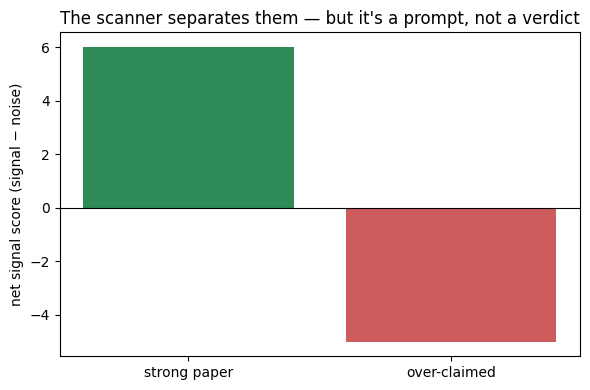

In [5]:
strong = score_claims({
    "strong_baselines": True, "released_code": True, "error_bars": True,
    "ablations": True, "honest_limits": True, "scales": True,
    "cherry_picked": False, "sota_on_one": False, "no_baseline_tuning": False,
})
weak = score_claims({
    "strong_baselines": False, "released_code": False, "error_bars": False,
    "ablations": False, "cherry_picked": True, "sota_on_one": True,
    "no_baseline_tuning": True, "vague_method": True, "benchmark_only": True,
})
print("Strong paper:", strong)
print("Over-claimed:", weak)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["strong paper", "over-claimed"], [strong["net"], weak["net"]],
       color=["seagreen", "indianred"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("net signal score (signal − noise)")
ax.set_title("The scanner separates them — but it's a prompt, not a verdict")
plt.tight_layout(); plt.show()

The net score isn't a verdict — a great paper can lack error bars, a bad one can ship code. Its value is forcing the questions, so good *writing* doesn't get mistaken for good *evidence*.

## 3. The reading list as data

Not a flat bibliography — a queryable dataset. Sort it into reading order, filter by area, and see the map back over the whole course.

In [6]:
print("READ IN THIS ORDER (foundational → important → frontier; oldest first within a tier):\n")
tier = None
for p in reading_order():
    if p.tier != tier:
        tier = p.tier
        print(f"  --- {tier.upper()} ---")
    mod = f"M{p.course_module}" if p.course_module is not None else "  "
    print(f"    {p.year}  {p.title:52s} [{p.area:12s}] {mod}")

READ IN THIS ORDER (foundational → important → frontier; oldest first within a tier):

  --- FOUNDATIONAL ---
    2017  Attention Is All You Need                            [transformers] M4
    2020  Language Models are Few-Shot Learners                [scaling     ] M0
    2020  Scaling Laws for Neural Language Models              [scaling     ] M22
    2022  Training Compute-Optimal Large Language Models       [scaling     ] M22
    2022  Training LMs to follow instructions with human feedback [posttraining] M14
    2023  Direct Preference Optimization                       [posttraining] M17
  --- IMPORTANT ---
    2017  Decoupled Weight Decay Regularization                [pretraining ] M8
    2019  ZeRO: Memory Optimizations Toward Training Trillion-Param Models [systems     ] M10
    2021  LoRA: Low-Rank Adaptation of Large Language Models   [posttraining] M16
    2022  FlashAttention                                       [systems     ] M4
    2023  QLoRA: Efficient Finetuning o

In [7]:
# Filter to one area when you want to go deep.
print("Everything on POST-TRAINING, in reading order:\n")
post = sorted(filter_papers(area="posttraining"), key=lambda p: p.year)
for p in post:
    print(f"  {p.year}  {p.title}")
    print(f"        why: {p.why}")

Everything on POST-TRAINING, in reading order:

  2021  LoRA: Low-Rank Adaptation of Large Language Models
        why: Fine-tune 0.1% of the weights, keep ~all the quality. The default in practice.
  2022  Training LMs to follow instructions with human feedback
        why: Defined the modern post-training stack. SFT then RLHF.
  2023  Direct Preference Optimization
        why: Made RLHF practical: a classification loss, no reward model, no RL loop.
  2023  QLoRA: Efficient Finetuning of Quantized LLMs
        why: 4-bit base + LoRA. Fine-tune a 65B model on one consumer GPU.
  2024  Tülu 3
        why: The most thoroughly documented open end-to-end post-training recipe.
  2025  DeepSeek-R1
        why: Reasoning via RL with verifiable rewards. GRPO, R1-Zero.
  2026  Self-Distillation Fine-Tuning
        why: The model as its own teacher; fights catastrophic forgetting.


Nearly every paper links to the course module where you *implemented* its idea. You didn't read DPO — you built it (Module 17). That's the difference this course is trying to make.

## 4. Finding the seminal papers via the citation graph

In a new area, start where the most arrows point. We rank the reading list by how much work transitively depends on each paper — `most_foundational()`.

In [8]:
ranked = most_foundational()
title_of = {p.key: p.title for p in READING_LIST}
print("MOST FOUNDATIONAL (by transitive citation reach):\n")
for key, reach in ranked:
    print(f"  {reach:2d} depend on  ->  {title_of.get(key, key)}")

MOST FOUNDATIONAL (by transitive citation reach):

  14 depend on  ->  Attention Is All You Need
  11 depend on  ->  Language Models are Few-Shot Learners
   4 depend on  ->  Decoupled Weight Decay Regularization
   4 depend on  ->  Training LMs to follow instructions with human feedback
   3 depend on  ->  Direct Preference Optimization
   3 depend on  ->  Scaling Laws for Neural Language Models
   3 depend on  ->  ZeRO: Memory Optimizations Toward Training Trillion-Param Models
   2 depend on  ->  Training Compute-Optimal Large Language Models
   2 depend on  ->  FlashAttention
   1 depend on  ->  DeepSeek-V3 Technical Report
   1 depend on  ->  LoRA: Low-Rank Adaptation of Large Language Models
   0 depend on  ->  Chinchilla Scaling: A replication attempt
   0 depend on  ->  Adding Error Bars to Evals
   0 depend on  ->  The Llama 3 Herd of Models
   0 depend on  ->  QLoRA: Efficient Finetuning of Quantized LLMs
   0 depend on  ->  DeepSeek-R1
   0 depend on  ->  Self-Distillation F

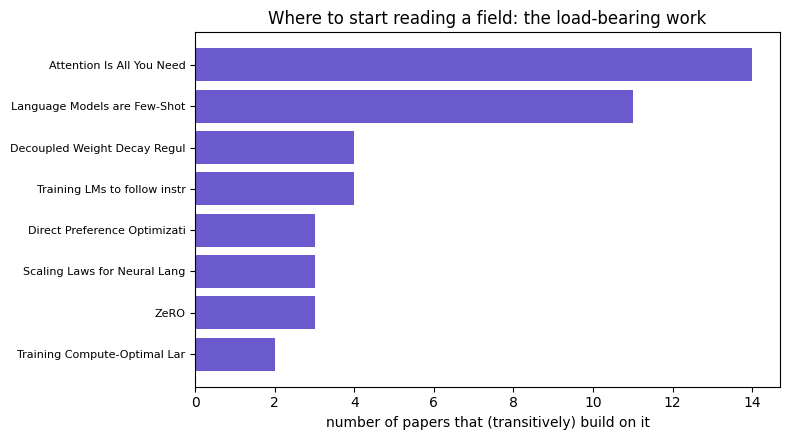

In [9]:
# Visualize the top of the ranking.
top = ranked[:8]
labels = [title_of[k].split(":")[0][:28] for k, _ in top]
reach = [r for _, r in top]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(top)), reach, color="slateblue")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("number of papers that (transitively) build on it")
ax.set_title("Where to start reading a field: the load-bearing work")
plt.tight_layout(); plt.show()

"Attention Is All You Need" sits at the root — almost everything descends from it — followed by GPT-3. That ranking *is* your orientation order: start where the arrows converge, read outward toward the leaves (the research frontier). In real life you'd run this over the Semantic Scholar or arXiv citation API; the mechanic is identical.

## The takeaway

The techniques in this course will drift. The method in this module won't:

1. **Triage** in three passes — decide what *not* to read, fast.
2. **Discern** signal from noise — make good writing earn your trust, don't grant it.
3. **Reproduce** the one thing that matters — the only way to know you understand it, and the best thing you can put in a portfolio.

Next, the final module — **Module 22, Scaling Intuitions** — where the small runs you did become the arithmetic behind the runs that cost $50M.